In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_pinball_loss

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data
from data.model_features import get_grouped_model_feature_columns
from models.gradient_boosting import (
    train_gradient_boosting,
    predict_gradient_boosting,
    get_transformed_predictions,
    get_feature_importances,
)
from evaluation.model_evaluation import (
    run_regression_evaluation,
    plot_actual_vs_predicted,
    plot_residual_distribution,
    plot_tail_comparison,
    plot_grouped_actual_vs_predicted,
)
from evaluation.shap_analysis import (
    run_shap_analysis,
    plot_shap_bar,
    plot_shap_beeswarm,
    plot_shap_waterfall,
    plot_shap_importance_dataframe,
)

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False
)

print("Shape:", df.shape)
display(df.head())
display(data_summary(df))

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


In [3]:
feature_cols = get_grouped_model_feature_columns(
    df,
    target_col=target
)

print(f"Number of features used: {len(feature_cols)}")
print(feature_cols)

print("Hospitalisation groups:")
print(df["hospitalizations_grouped"].value_counts().sort_index())

print("Chronic count groups:")
print(df["chronic_count_grouped"].value_counts().sort_index())

print("Days hospitalised groups:")
print(df["days_hospitalized_grouped"].value_counts().sort_index())

Number of features used: 47
['age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'hospitalizations_grouped', 'chronic_count_grouped', 'days_hospitalized_grouped']
Hospitalisation groups:
hospitalizations_grouped
0     91031
1      8582
2+      387
Name: count, dtype: int64
Chronic count groups:
chronic_count_grouped
0     46532
1     37579
2     13111
3      2452

In [4]:
gb_result = train_gradient_boosting(
    df=df,
    target_col=target,
    feature_cols=feature_cols,
    target_transform="log1p",
    loss="squared_error",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    test_size=0.20,
    random_state=42,
    numeric_impute_strategy="median",
    categorical_impute_strategy="most_frequent",
    scale_numeric=False,
    one_hot_encode=True,
)

print("Model loss:", gb_result.loss)
print("Quantile alpha:", gb_result.quantile_alpha)
print("Train shape:", gb_result.x_train.shape)
print("Test shape:", gb_result.x_test.shape)

Model loss: squared_error
Quantile alpha: None
Train shape: (80000, 47)
Test shape: (20000, 47)


In [5]:
y_pred_cost = predict_gradient_boosting(
    model=gb_result.model,
    df=gb_result.x_test,
    target_transform=gb_result.target_transform,
    clip_min=0,
)

y_pred_log = get_transformed_predictions(
    model=gb_result.model,
    df=gb_result.x_test,
)

evaluation_results = run_regression_evaluation(
    x_test=gb_result.x_test,
    y_true=gb_result.y_test,
    y_pred=y_pred_cost,
    y_true_transformed=np.log1p(gb_result.y_test),
    y_pred_transformed=y_pred_log,
    actual_col="actual_cost",
    predicted_col="predicted_cost",
    transformed_actual_col="actual_log_cost",
    transformed_predicted_col="predicted_log_cost",
    group_cols=[
        "hospitalizations_grouped",
        "chronic_count_grouped",
        "days_hospitalized_grouped",
    ],
    original_scale_name="cost",
    transformed_scale_name="log",
)

predictions = evaluation_results["predictions"]
metrics_df = evaluation_results["metrics"]
tail_df = evaluation_results["tail_summary"]

display(predictions.head())
display(metrics_df)
display(tail_df.round(2))

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,predicted_cost,residual,absolute_error,actual_log_cost,predicted_log_cost
75721,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,3,...,1,1,1,4+,1640.86,4517.929080,-2877.069080,2877.069080,7.403585,8.416030
80184,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,0,...,0,0,0,0,2306.61,1527.030726,779.579274,779.579274,7.743968,7.331735
19864,55,Male,East,Urban,226200.0,HS,Married,Employed,3,1,...,0,0,0,0,1015.03,2622.018294,-1606.988294,1606.988294,6.923658,7.872081
76699,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,1,...,0,0,1,0,1136.82,2050.417427,-913.597427,913.597427,7.036869,7.626286
92991,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,1,...,0,0,2,0,3990.84,3205.367182,785.472818,785.472818,8.292008,8.072894


,value
rmse_cost,2970.5019
r2_cost,0.1033
pearson_correlation_cost,0.4193
sdep_cost,2870.1368
bias_cost,765.9035
mae_cost,1659.4716
mean_actual_cost,3027.7912
mean_predicted_cost,2261.8877
median_actual_cost,2096.4650
median_predicted_cost,2077.5260


,statistic,actual_cost,predicted_cost,difference,relative_difference
0,mean,3027.79,2261.89,765.90,0.25
1,p50,2096.46,2077.53,18.94,0.01
2,p90,6324.06,3606.41,2717.65,0.43
3,p95,8695.57,4220.23,4475.34,0.51
4,p99,15189.61,5242.38,9947.24,0.65
5,max,65724.90,8644.83,57080.07,0.87


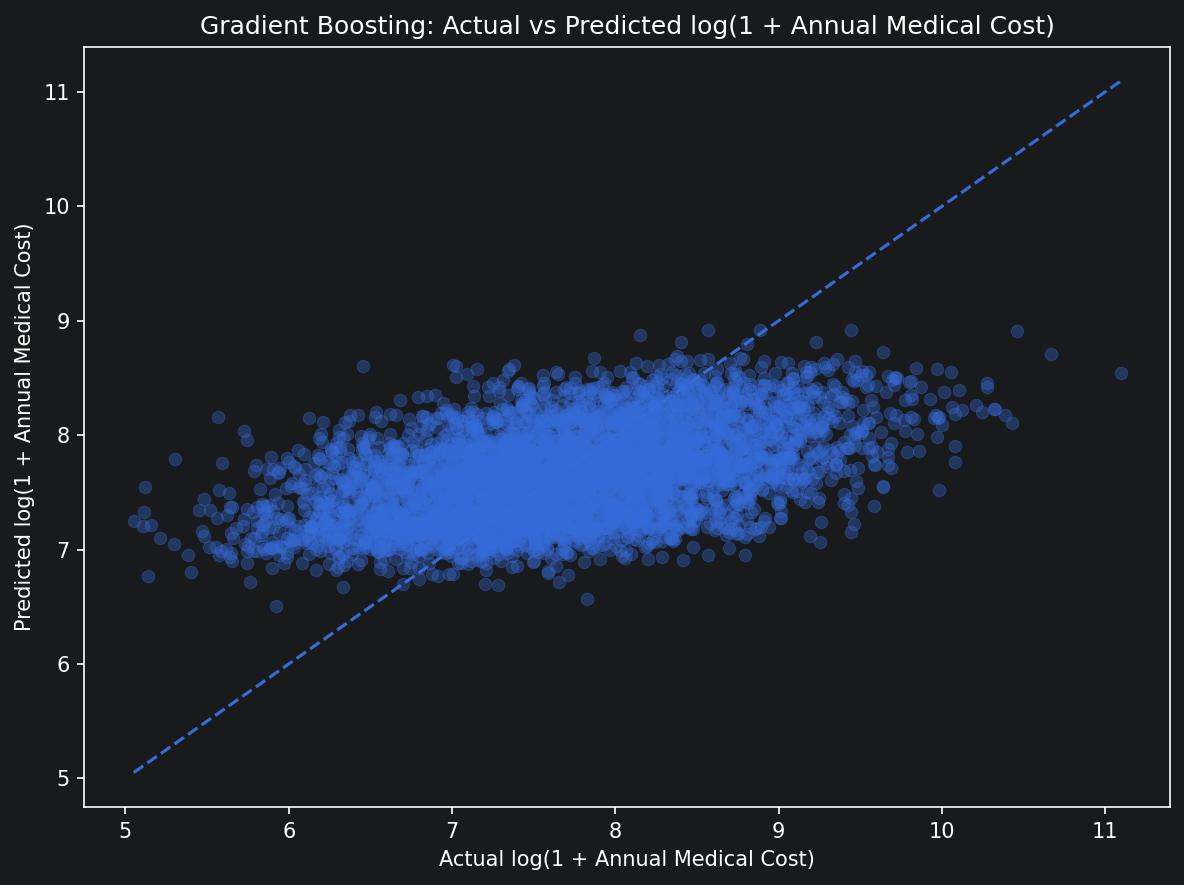

In [6]:
plot_actual_vs_predicted(
    data=predictions,
    actual_col="actual_log_cost",
    predicted_col="predicted_log_cost",
    title="Gradient Boosting: Actual vs Predicted log(1 + Annual Medical Cost)",
    xlabel="Actual log(1 + Annual Medical Cost)",
    ylabel="Predicted log(1 + Annual Medical Cost)",
)
plt.show()

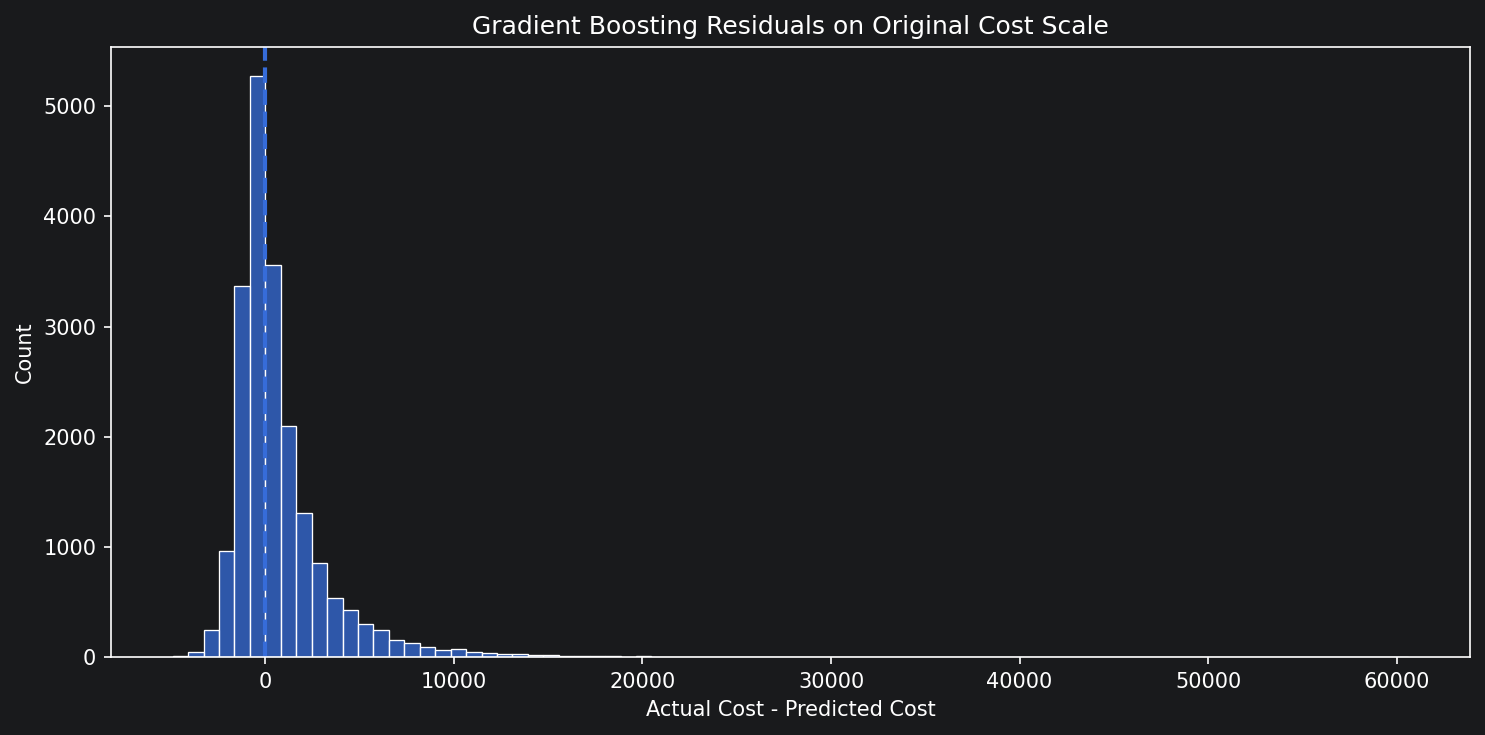

In [7]:
plot_residual_distribution(
    data=predictions,
    residual_col="residual",
    title="Gradient Boosting Residuals on Original Cost Scale",
    xlabel="Actual Cost - Predicted Cost",
)
plt.show()

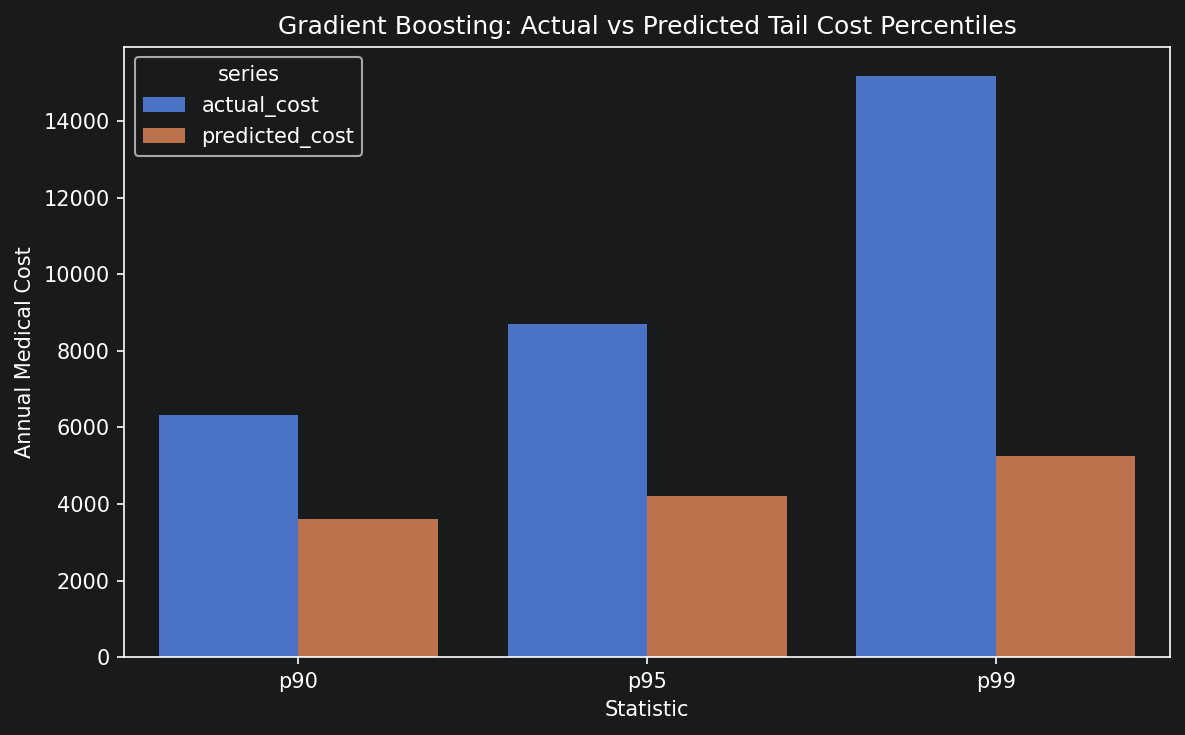

In [8]:
plot_tail_comparison(
    tail_df=tail_df,
    statistics=("p90", "p95", "p99"),
    actual_col="actual_cost",
    predicted_col="predicted_cost",
    title="Gradient Boosting: Actual vs Predicted Tail Cost Percentiles",
    ylabel="Annual Medical Cost",
)
plt.show()

In [9]:
hospital_model_summary = evaluation_results["group_summary_hospitalizations_grouped"]
chronic_model_summary = evaluation_results["group_summary_chronic_count_grouped"]
days_hospitalized_model_summary = evaluation_results["group_summary_days_hospitalized_grouped"]

display(hospital_model_summary)
display(chronic_model_summary)
display(days_hospitalized_model_summary)

,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
hospitalizations_grouped,,,,,,,,,,,,,,,
0,18188,2813.47,2117.30,1987.04,2000.42,1538.94,5833.04,3224.97,2608.07,7987.55,3703.37,4284.18,13713.35,4758.68,8954.67
1,1742,5042.25,3659.21,3657.32,3636.10,2775.60,10087.07,4976.04,5111.03,13129.64,5309.66,7819.98,23494.29,6196.33,17297.96
2+,70,8582.41,5057.17,4906.64,5005.03,5201.69,18614.89,6523.79,12091.11,28464.62,6963.70,21500.92,37382.90,7842.32,29540.58


,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
chronic_count_grouped,,,,,,,,,,,,,,,
0,9290,2212.49,1639.51,1575.86,1483.27,1206.14,4448.06,2313.78,2134.27,6168.38,2759.18,3409.20,10667.34,3837.79,6829.55
1,7506,3316.46,2509.05,2398.17,2302.20,1821.05,6755.76,3586.90,3168.86,9085.72,4105.64,4980.08,14794.49,4745.90,10048.60
2,2644,4442.01,3343.74,3249.29,3082.63,2449.28,8994.36,4715.23,4279.13,12169.45,5081.49,7087.96,19870.09,5842.96,14027.13
3,504,5793.30,4108.79,4287.90,3881.19,3145.99,10940.31,5482.63,5457.68,16011.83,5911.84,10099.99,24415.33,7044.24,17371.10
4+,56,7927.76,4680.66,6165.62,4487.13,4538.08,16432.71,5894.95,10537.76,19626.42,7395.29,12231.12,22124.42,7515.46,14608.96


,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
days_hospitalized_grouped,,,,,,,,,,,,,,,
0,18188,2813.47,2117.30,1987.04,2000.42,1538.94,5833.04,3224.97,2608.07,7987.55,3703.37,4284.18,13713.35,4758.68,8954.67
1-3,745,3934.41,2943.56,2884.85,2764.54,2251.96,7785.04,4176.80,3608.24,11561.65,4566.14,6995.50,18065.42,5366.19,12699.23
4+,1067,6048.02,4250.61,4450.08,4172.29,3300.38,11792.20,5322.36,6469.84,15435.36,5815.97,9619.39,29784.17,6949.97,22834.19


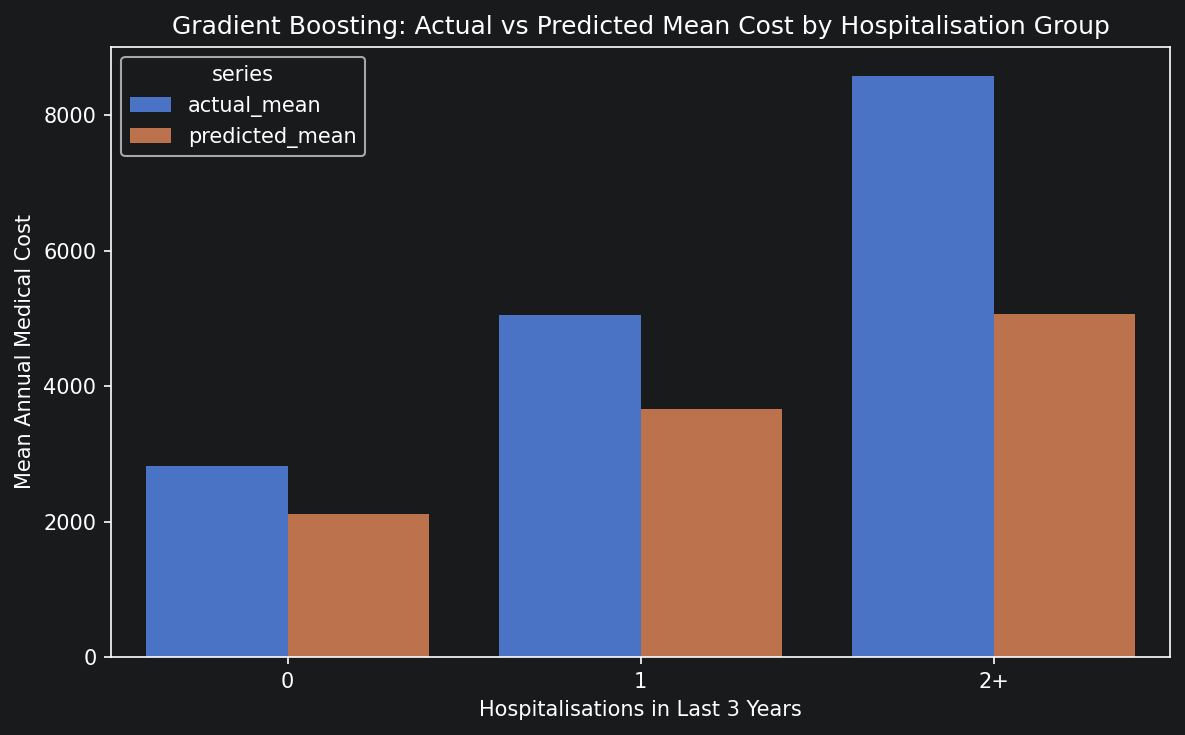

In [10]:
plot_grouped_actual_vs_predicted(
    grouped_summary=hospital_model_summary,
    group_col="hospitalizations_grouped",
    title="Gradient Boosting: Actual vs Predicted Mean Cost by Hospitalisation Group",
    xlabel="Hospitalisations in Last 3 Years",
    ylabel="Mean Annual Medical Cost",
)
plt.show()

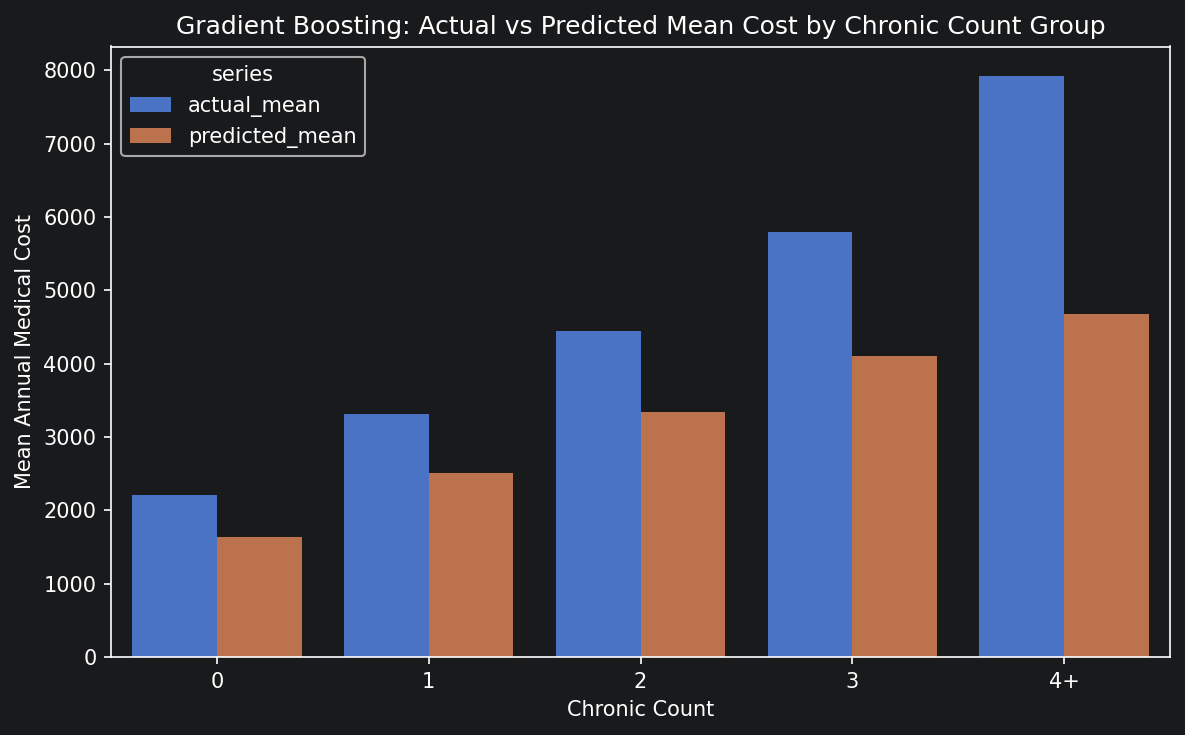

In [11]:
plot_grouped_actual_vs_predicted(
    grouped_summary=chronic_model_summary,
    group_col="chronic_count_grouped",
    title="Gradient Boosting: Actual vs Predicted Mean Cost by Chronic Count Group",
    xlabel="Chronic Count",
    ylabel="Mean Annual Medical Cost",
)
plt.show()

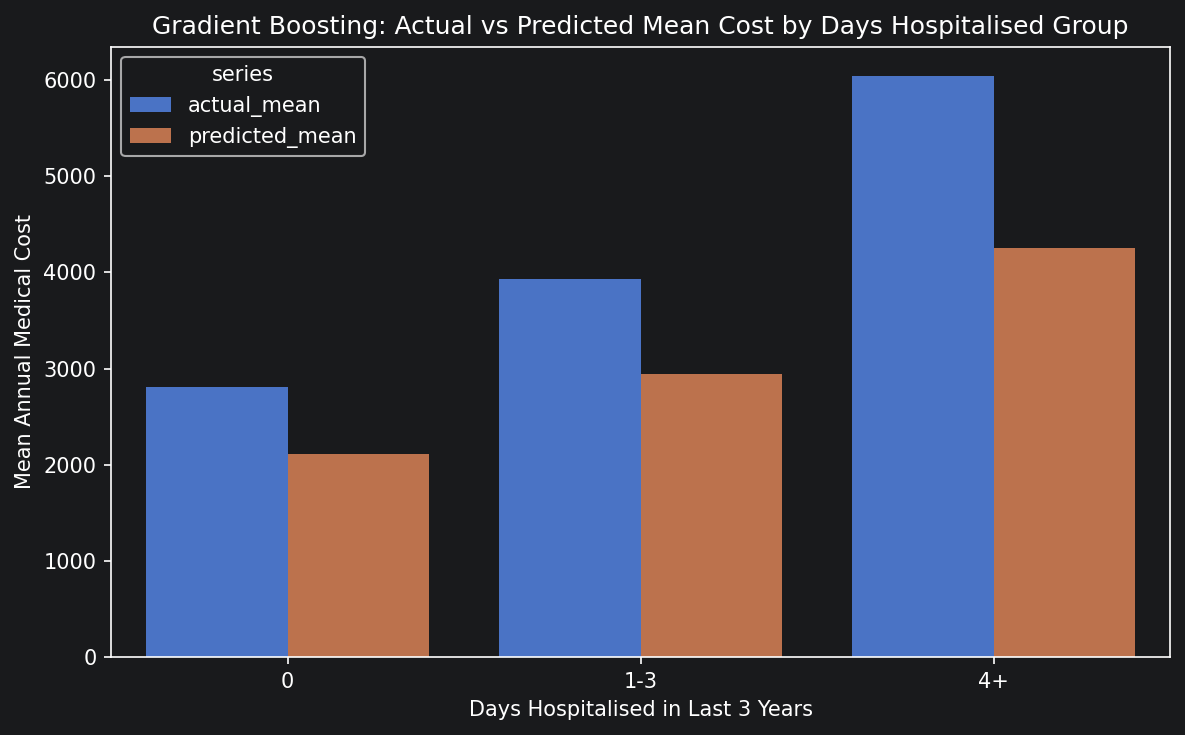

In [12]:
plot_grouped_actual_vs_predicted(
    grouped_summary=days_hospitalized_model_summary,
    group_col="days_hospitalized_grouped",
    title="Gradient Boosting: Actual vs Predicted Mean Cost by Days Hospitalised Group",
    xlabel="Days Hospitalised in Last 3 Years",
    ylabel="Mean Annual Medical Cost",
)
plt.show()

In [13]:
importance_df = get_feature_importances(gb_result)

display(importance_df.head(30))

,feature,importance
0,risk_score,0.323497
1,chronic_count_grouped_0,0.304369
2,hospitalizations_grouped_0,0.079964
3,days_hospitalized_grouped_4+,0.048124
4,smoker_Never,0.046511
5,days_hospitalized_grouped_0,0.044305
6,visits_last_year,0.040339
7,smoker_Current,0.026808
8,chronic_count_grouped_1,0.025522
9,bmi,0.017251


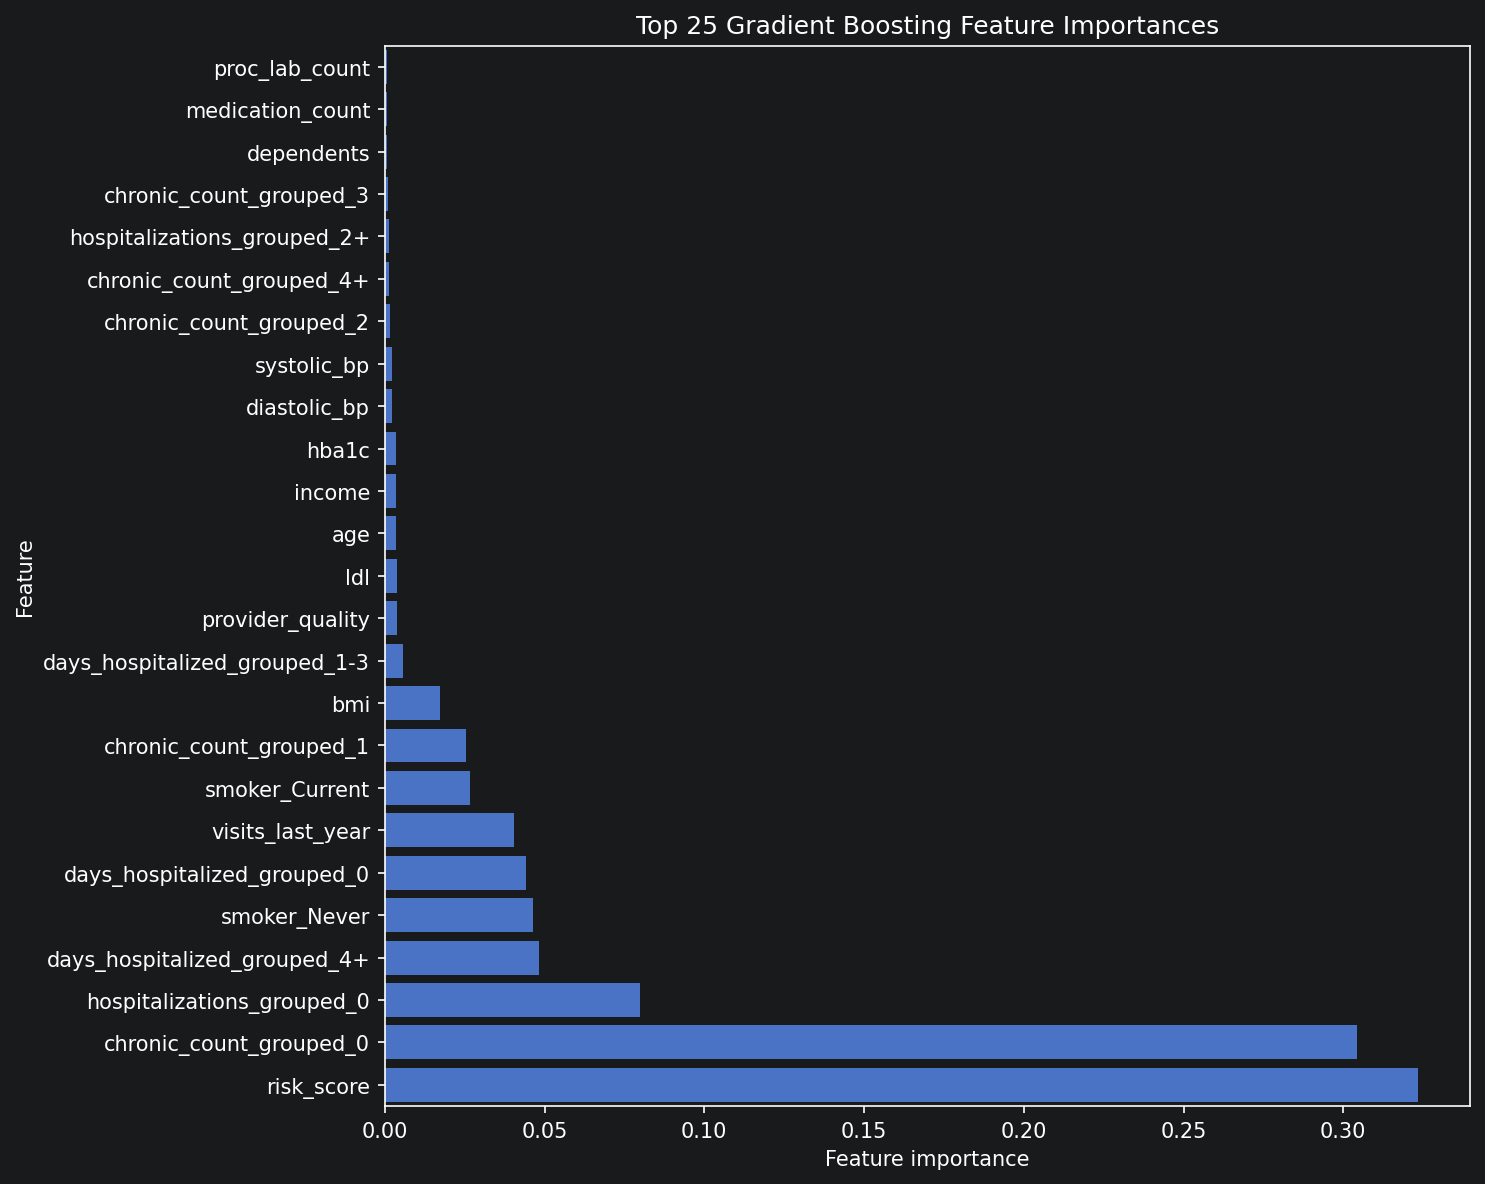

In [14]:
plt.figure(figsize=(10, 8), dpi=150)

top_importance = importance_df.head(25).sort_values("importance")

sns.barplot(
    data=top_importance,
    x="importance",
    y="feature"
)

plt.title("Top 25 Gradient Boosting Feature Importances")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [15]:
shap_result = run_shap_analysis(
    model=gb_result.model,
    x_background=gb_result.x_train,
    x_explain=gb_result.x_test,
    model_type="tree",
    use_transformed_features=True,
    background_size=500,
    explain_size=2000,
    masker_max_samples=500,
    random_state=42,
)

display(shap_result.importance_df.head(30))

,feature,mean_abs_shap,mean_shap
0,chronic_count_grouped_0,0.155764,-5.554868e-03
1,risk_score,0.139152,1.029576e-02
2,smoker_Never,0.063594,-1.202402e-03
3,visits_last_year,0.055412,1.763272e-04
4,hospitalizations_grouped_0,0.038732,2.179684e-03
5,chronic_count_grouped_1,0.031042,9.992786e-03
6,bmi,0.030326,-4.578931e-04
7,days_hospitalized_grouped_4+,0.028934,-7.893394e-04
8,days_hospitalized_grouped_0,0.027750,1.913627e-03
9,smoker_Current,0.024273,-3.641665e-04


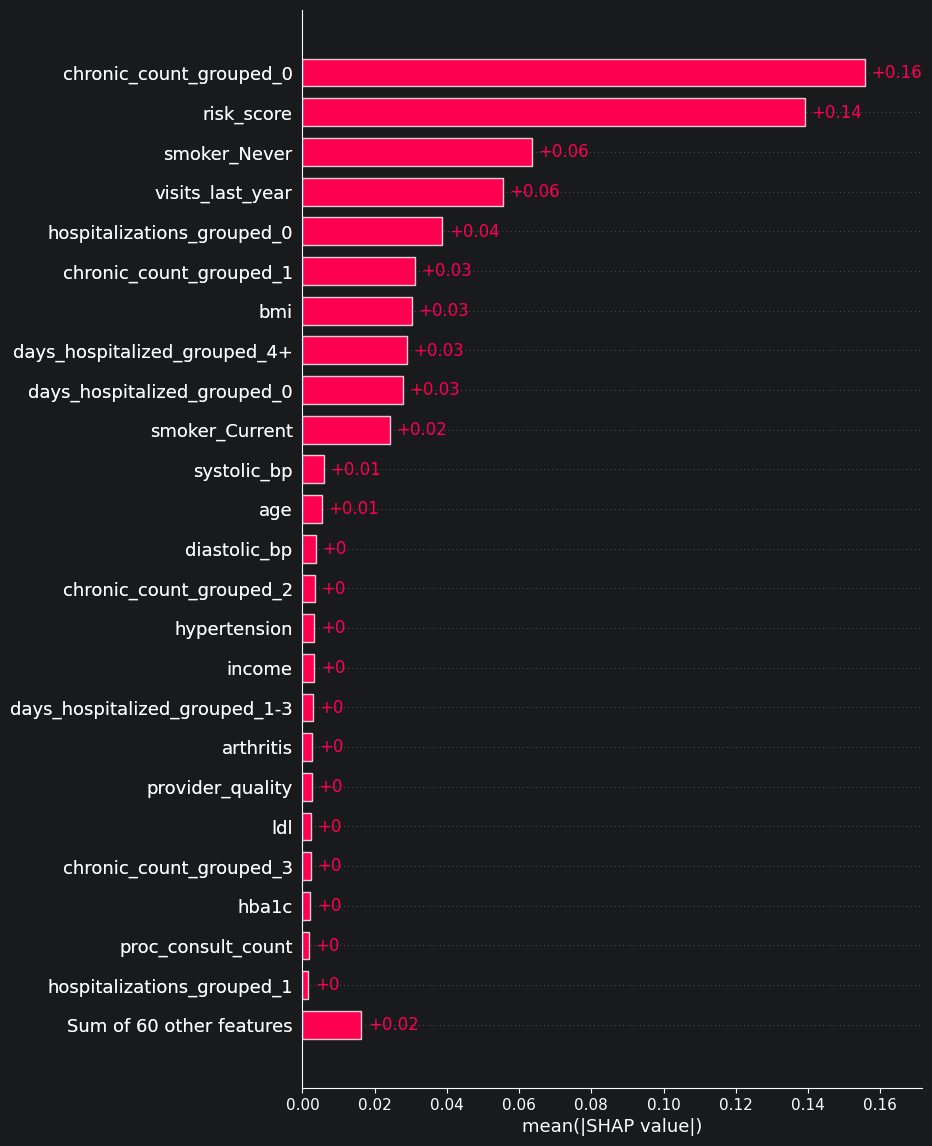

In [16]:
plot_shap_bar(shap_result, max_display=25)

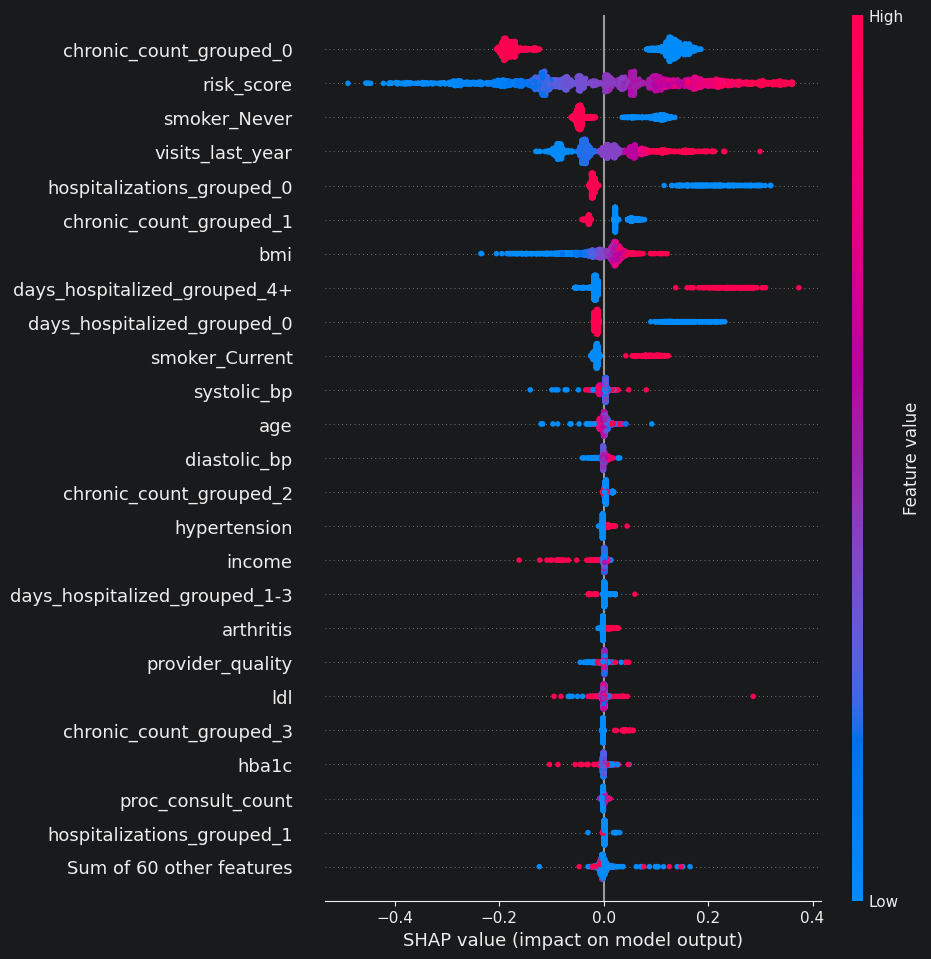

In [17]:
plot_shap_beeswarm(
    shap_result,
    max_display=25,
    text_colour="#eeeeee"
);

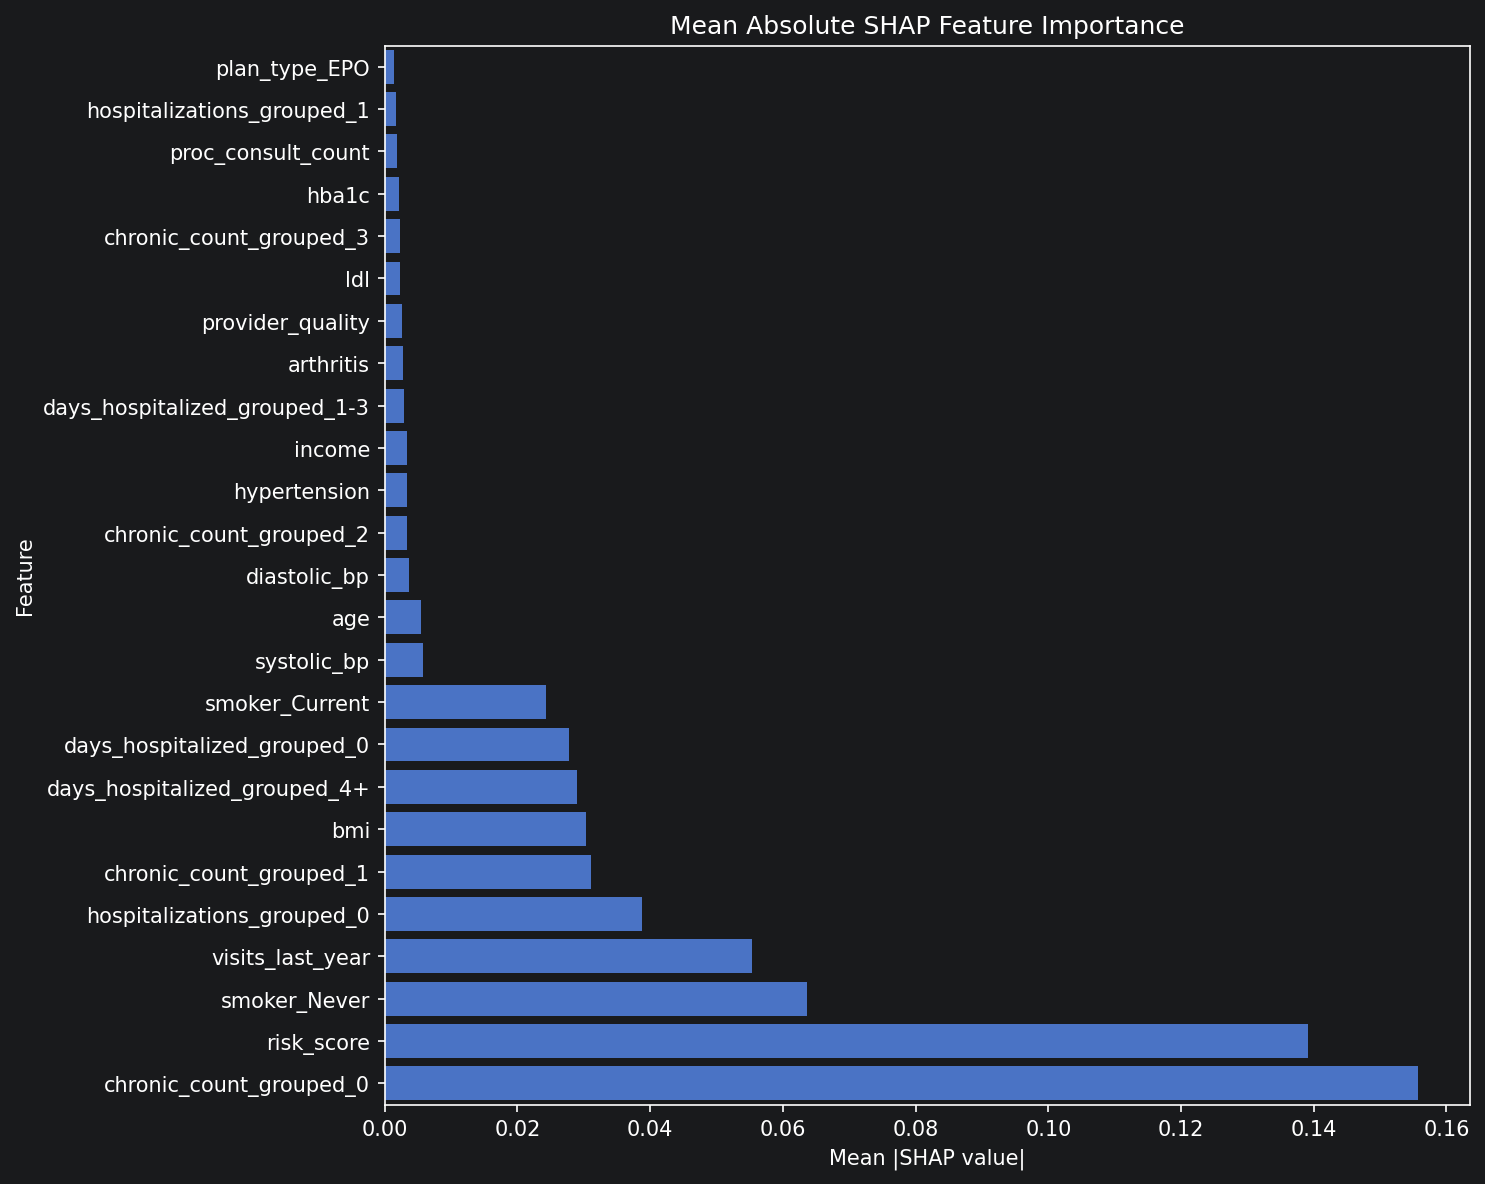

In [18]:
plot_shap_importance_dataframe(shap_result, max_display=25)
plt.show()

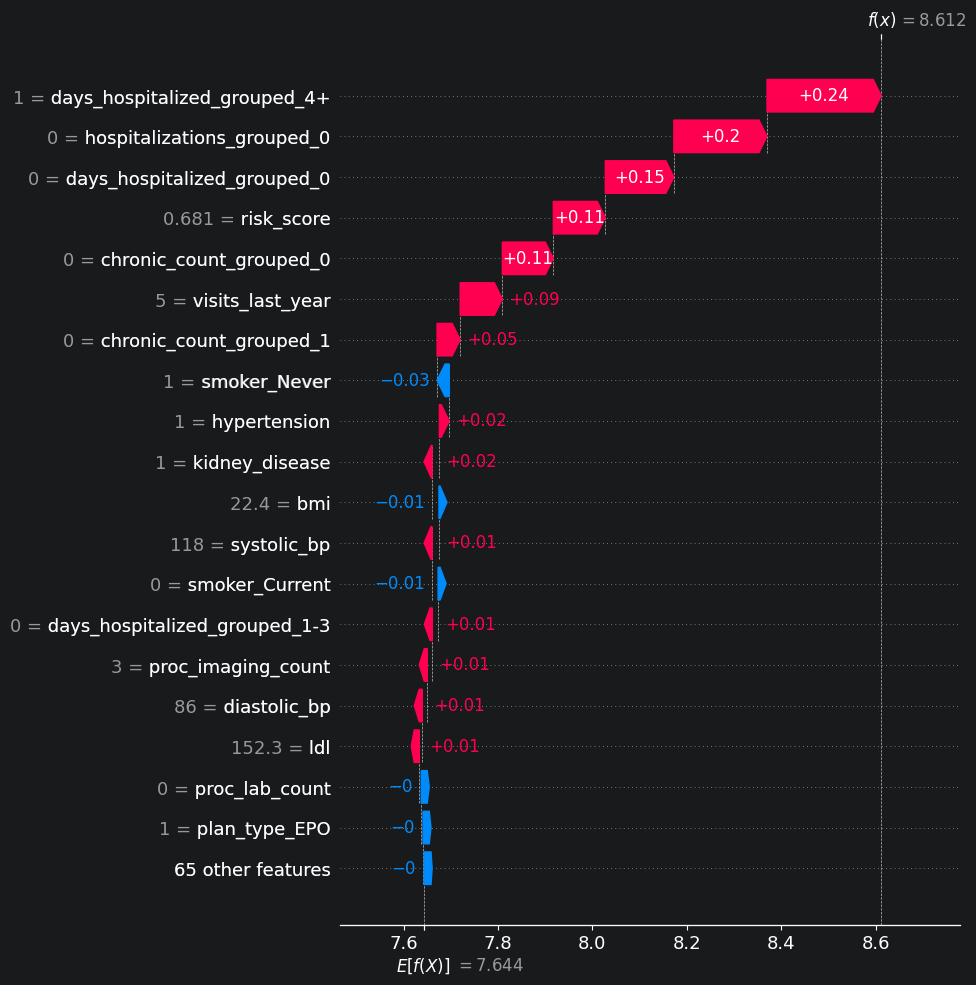

In [19]:
plot_shap_waterfall(
    shap_result,
    row_number=0,
    max_display=20,
)

In [20]:
quantile_alphas = [0.90, 0.95, 0.99]
quantile_results = {}
quantile_rows = []

for quantile_alpha in quantile_alphas:
    quantile_result = train_gradient_boosting(
        df=df,
        target_col=target,
        feature_cols=feature_cols,
        target_transform="log1p",
        loss="quantile",
        quantile_alpha=quantile_alpha,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        test_size=0.20,
        random_state=42,
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=False,
        one_hot_encode=True,
    )

    y_quantile_pred_cost = predict_gradient_boosting(
        model=quantile_result.model,
        df=quantile_result.x_test,
        target_transform=quantile_result.target_transform,
        clip_min=0,
    )

    observed_coverage = np.mean(quantile_result.y_test <= y_quantile_pred_cost)
    pinball_loss = mean_pinball_loss(
        quantile_result.y_test,
        y_quantile_pred_cost,
        alpha=quantile_alpha,
    )

    quantile_results[quantile_alpha] = {
        "result": quantile_result,
        "predicted_quantile_cost": y_quantile_pred_cost,
    }

    quantile_rows.append(
        {
            "quantile_alpha": quantile_alpha,
            "observed_coverage": observed_coverage,
            "pinball_loss_cost_scale": pinball_loss,
            "actual_cost_quantile": quantile_result.y_test.quantile(quantile_alpha),
            "mean_predicted_conditional_quantile": np.mean(y_quantile_pred_cost),
            "predicted_cost_quantile": np.quantile(y_quantile_pred_cost, quantile_alpha),
        }
    )

quantile_summary = pd.DataFrame(quantile_rows)
display(quantile_summary.round(4))

,quantile_alpha,observed_coverage,pinball_loss_cost_scale,actual_cost_quantile,mean_predicted_conditional_quantile,predicted_cost_quantile
0,0.90,0.8960,598.8689,6324.0610,5879.7270,9311.5005
1,0.95,0.9467,409.0378,8695.5700,7725.6606,14525.8783
2,0.99,0.9892,142.2076,15189.6144,12763.0922,27294.3009


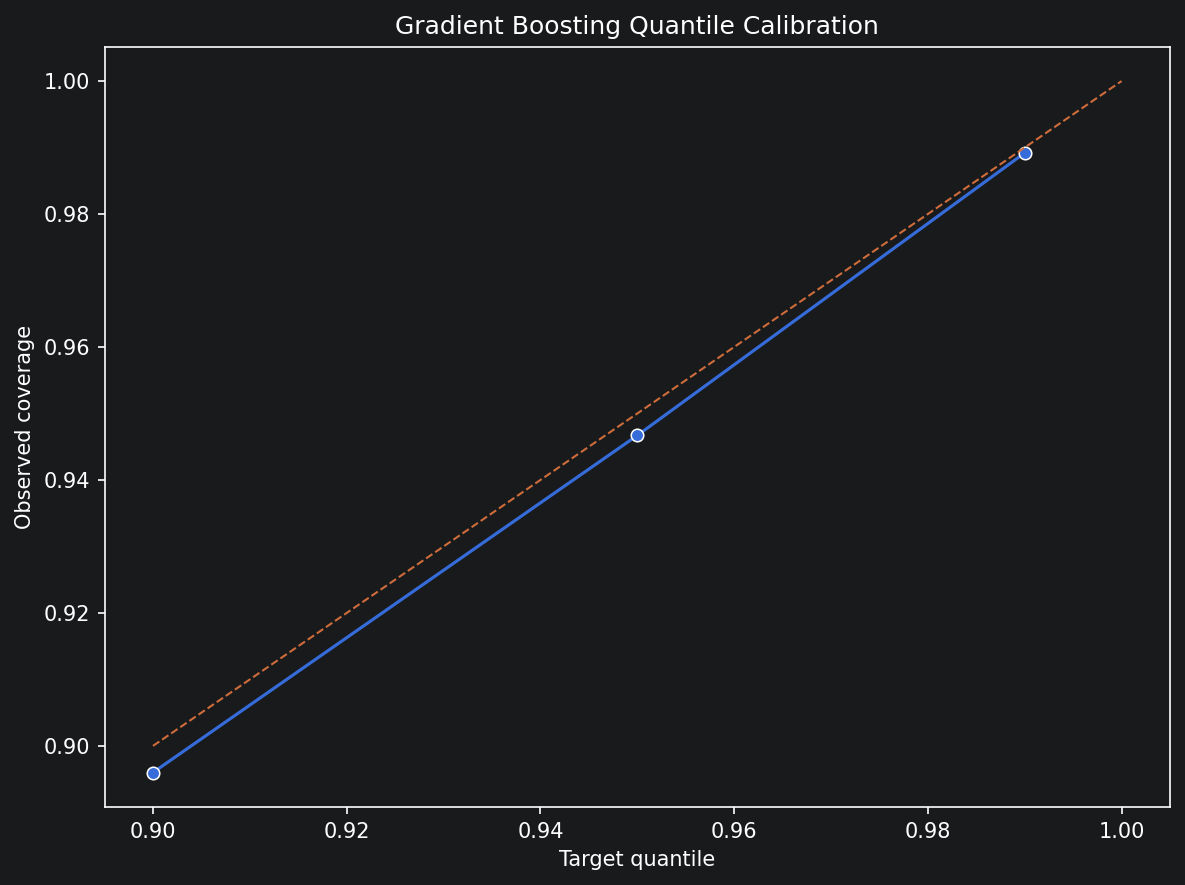

In [21]:
plt.figure(figsize=(8, 6), dpi=150)

sns.lineplot(
    data=quantile_summary,
    x="quantile_alpha",
    y="observed_coverage",
    marker="o",
)

plt.plot([0.90, 1.00], [0.90, 1.00], linestyle="--", linewidth=1)
plt.title("Gradient Boosting Quantile Calibration")
plt.xlabel("Target quantile")
plt.ylabel("Observed coverage")
plt.tight_layout()
plt.show()